# Laboratory 5: Probability and Density Estimation

In questo laboratorio si affrontano i seguenti argomenti:

1. Multivariate Gaussian Density
2. Calcolo della log-density (logpdf)
3. Stima dei parametri ML (Maximum Likelihood)
4. Calcolo della log-likelihood
5. Visualizzazione e validazione dei risultati

## 1. Multivariate Gaussian Density

La densità gaussiana multivariata (MVG) è definita come:

$$
N(x|\mu, \Sigma) = \frac{1}{(2\pi)^{M/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu)^T \Sigma^{-1} (x-\mu)\right)
$$

Dove $M$ è la dimensione del vettore delle feature $x$, $\mu$ è la media e $\Sigma$ la matrice di covarianza.

### 1.1 Log-density della MVG

Per evitare problemi numerici, si lavora spesso con il logaritmo della densità:

$$
\log N(x|\mu, \Sigma) = -\frac{M}{2} \log 2\pi - \frac{1}{2} \log |\Sigma| - \frac{1}{2} (x-\mu)^T \Sigma^{-1} (x-\mu)
$$

## 2. Calcolo della log-density: funzione logpdf_GAU_ND

Utilizziamo la funzione `logpdf_GAU_ND` per calcolare la log-density di una MVG su un insieme di campioni.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))  # Aggiunge la cartella superiore al sys.path per importare moduli

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from MVG.logpdf_loglikelihood_GAU import logpdf_GAU_ND
from mean_covariance import vrow, vcol, compute_mu_C

### 2.1 Esempio 1D: confronto con soluzione

Calcoliamo la log-density per una Gaussiana 1D e confrontiamo con i valori di riferimento.

Differenza massima: 0.0


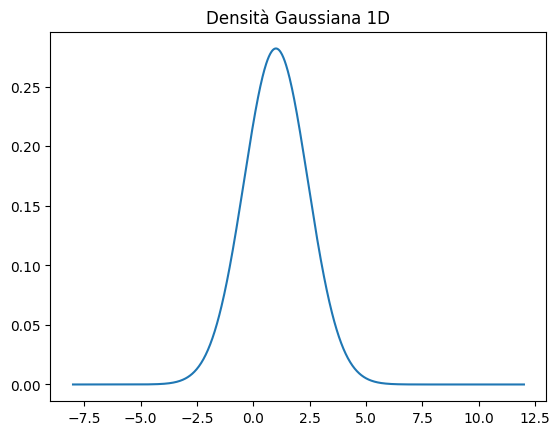

In [3]:
# Densità 1D: confronto con soluzione
XPlot = np.linspace(-8, 12, 1000)
m = np.ones((1,1)) * 1.0
C = np.ones((1,1)) * 2.0
pdfSol = np.load('../data/llGAU.npy')
pdfGau = logpdf_GAU_ND(vrow(XPlot), m, C)
print('Differenza massima:', np.abs(pdfSol - pdfGau).max())
plt.figure()
plt.plot(XPlot.ravel(), np.exp(pdfGau))
plt.title('Densità Gaussiana 1D')
plt.show()

### 2.2 Esempio ND: confronto con soluzione

Testiamo la funzione su dati multi-dimensionali.

In [4]:
# Densità ND: confronto con soluzione
XND = np.load('../data/XND.npy')
mu = np.load('../data/muND.npy')
C = np.load('../data/CND.npy')
pdfSol = np.load('../data/llND.npy')
pdfGau = logpdf_GAU_ND(XND, mu, C)
print('Differenza massima (ND):', np.abs(pdfSol - pdfGau).max())

Differenza massima (ND): 0.0


## 3. Stima dei parametri ML (Maximum Likelihood)

Calcoliamo la media empirica e la matrice di covarianza empirica per un dataset.

In [5]:
# Esempio su dati multi-dimensionali
XND = np.load('../data/XND.npy')
mu_ML, C_ML = compute_mu_C(XND)
print('mu_ML =', mu_ML.ravel())
print('C_ML =\n', C_ML)

mu_ML = [-0.07187197  0.05979594]
C_ML =
 [[0.94590166 0.09313534]
 [0.09313534 0.8229693 ]]


### 3.1 Stima ML su dati 1D

Applichiamo la stima ML su un dataset monodimensionale.

In [6]:
# Stima ML su dati 1D
X1D = np.load('../data/X1D.npy')
mu1D_ML, C1D_ML = compute_mu_C(X1D)
print('mu1D_ML =', mu1D_ML.ravel())
print('C1D_ML =', C1D_ML.ravel())

mu1D_ML = [1.9539157]
C1D_ML = [6.09542485]


## 4. Calcolo della log-likelihood

La log-likelihood è la somma delle log-density su tutti i campioni.

In [7]:
from MVG.logpdf_loglikelihood_GAU import compute_ll

# Log-likelihood su dati ND
ll_ND = compute_ll(XND, mu_ML, C_ML)
print('Log-likelihood ND:', ll_ND)

# Log-likelihood su dati 1D
ll_1D = compute_ll(X1D, mu1D_ML, C1D_ML)
print('Log-likelihood 1D:', ll_1D)

Log-likelihood ND: -270.70478023795044
Log-likelihood 1D: -23227.07765460272


### 4.1 Visualizzazione: confronto tra istogramma e densità stimata

Visualizziamo l'istogramma dei dati 1D e la densità stimata tramite ML.

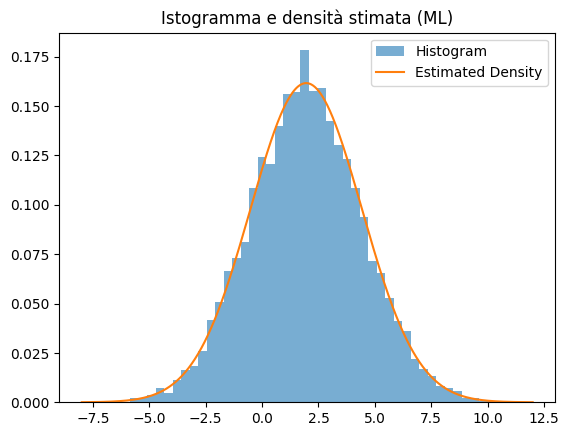

In [8]:
plt.figure()
plt.hist(X1D.ravel(), bins=50, density=True, alpha=0.6, label='Histogram')
XPlot = np.linspace(-8, 12, 1000)
plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND(vrow(XPlot), mu1D_ML, C1D_ML)), label='Estimated Density')
plt.title('Istogramma e densità stimata (ML)')
plt.legend()
plt.show()

## 5. Analisi della log-likelihood per diversi parametri

Verifichiamo che la log-likelihood è massima per i parametri ML e diminuisce per altri valori di $\mu$ e $\Sigma$.

In [9]:
# Log-likelihood per parametri diversi da ML
mu_wrong = mu1D_ML + 2
C_wrong = C1D_ML * 2
ll_wrong = compute_ll(X1D, mu_wrong, C_wrong)
print('Log-likelihood con parametri errati:', ll_wrong)
print('Log-likelihood ML:', ll_1D)

Log-likelihood con parametri errati: -25833.388292186915
Log-likelihood ML: -23227.07765460272


# Project: Analisi delle feature tramite modelli Gaussiani 1D

In questa sezione analizziamo la bontà dell'approssimazione gaussiana sulle singole feature delle diverse classi del dataset di progetto.

In [ ]:
# Load project data
import numpy as np
from mean_covariance import compute_mu_C, vrow, vcol
import matplotlib.pyplot as plt
from MVG.logpdf_loglikelihood_GAU import logpdf_GAU_ND

data = np.genfromtxt('../data/trainData.txt', delimiter=',', autostrip=True)
X = data[:, :-1].T  # [all row, all colums except the last one] = features (n_features, n_samples)
y = data[:, -1].astype(int)  # [all row, only the last column] = labels
print('Shape X:', X.shape, 'Shape y:', y.shape)
print('Unique labels:', np.unique(y))
print('Label counts:', [(label, (y==label).sum()) for label in np.unique(y)])

Shape X: (6, 6000) Shape y: (6000,)
Unique labels: [0 1]
Label counts: [(np.int64(0), np.int64(2990)), (np.int64(1), np.int64(3010))]


## Fit di modelli Gaussiani 1D alle feature delle classi

Per ogni classe e per ogni feature, stimiamo i parametri ML di una Gaussiana 1D e confrontiamo la densità stimata con l'istogramma normalizzato dei dati.

Fake Fingerprints - n_samples: 2990


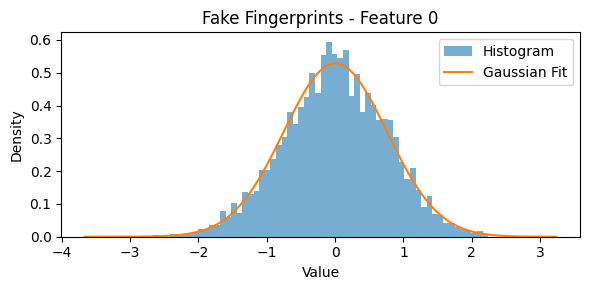

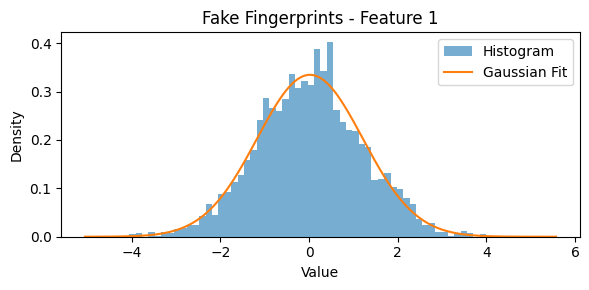

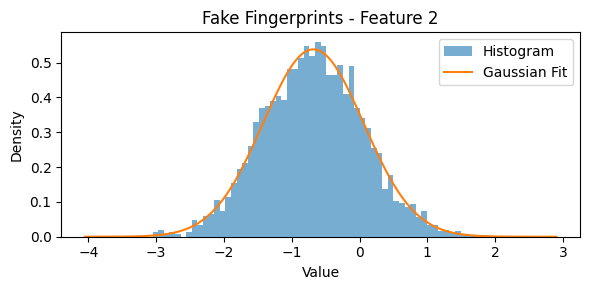

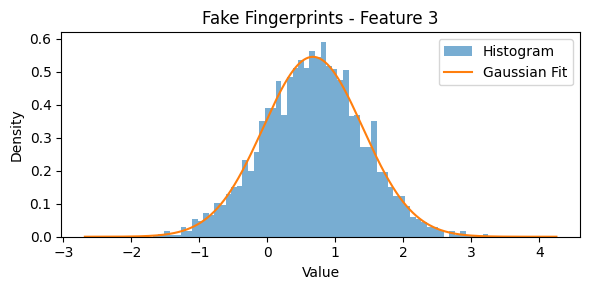

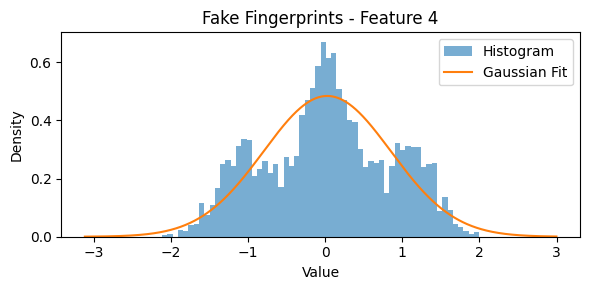

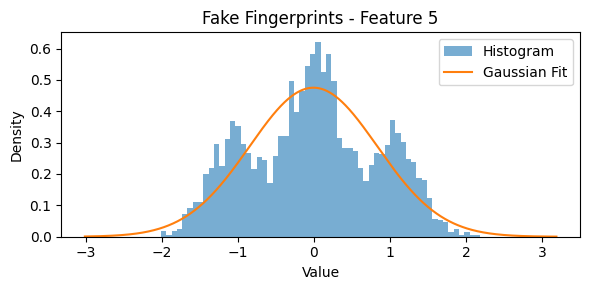

Genuine Fingerprints - n_samples: 3010


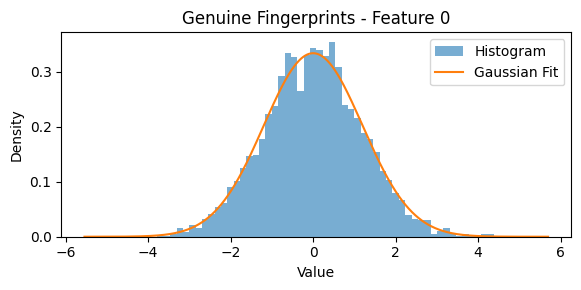

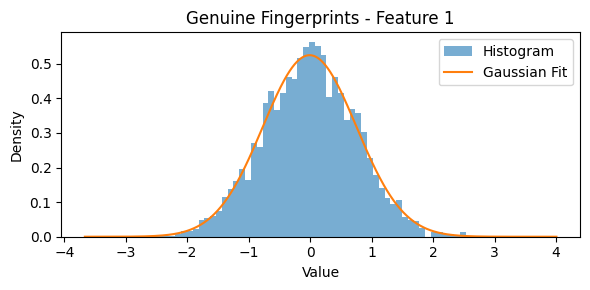

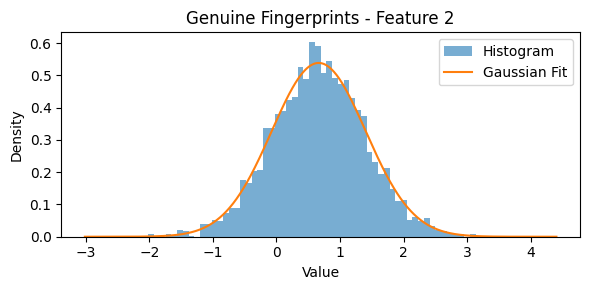

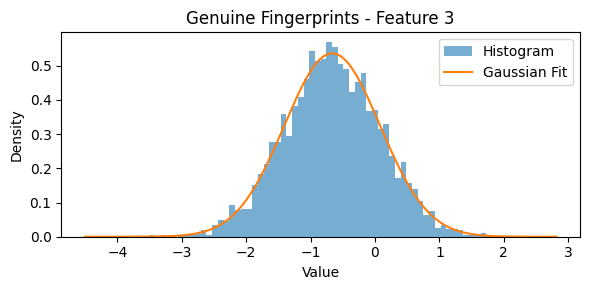

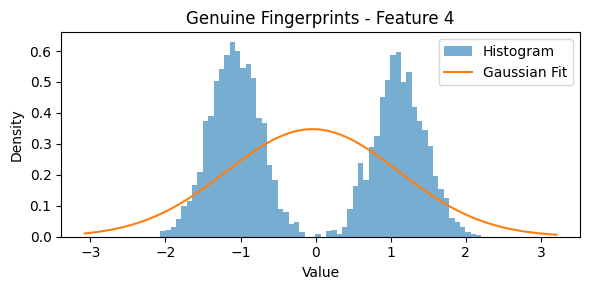

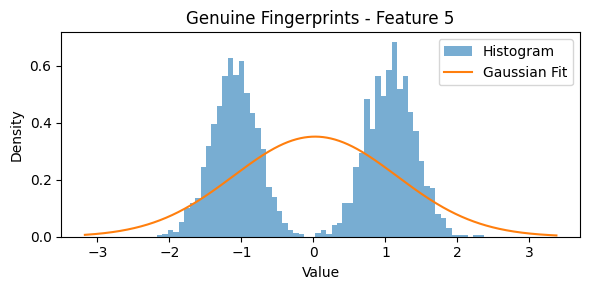

In [14]:
# Fit e plot per ogni feature e classe
n_features = X.shape[0]
labels = np.unique(y)
label_names = {0: 'Fake Fingerprints', 1: 'Genuine Fingerprints'}

for label in labels:
    Xc = X[:, y == label]
    print(f'{label_names[label]} - n_samples: {Xc.shape[1]}')
    for i in range(n_features):
        feature = Xc[i, :]
        mu, C = compute_mu_C(feature.reshape(1, -1))
        Xplot = np.linspace(feature.min()-1, feature.max()+1, 1000)
        plt.figure(figsize=(6, 3))
        plt.hist(feature, bins=60, density=True, alpha=0.6, label='Histogram')
        plt.plot(Xplot, np.exp(logpdf_GAU_ND(vrow(Xplot), mu, C)), label='Gaussian Fit')
        plt.title(f'{label_names[label]} - Feature {i}')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()

### Observations on the results

From the visual analysis of the fits:

- For most features, the estimated Gaussian density fits well the histogram of the data for each class.
- However, for the last features of each class, the empirical distribution clearly shows a non-Gaussian shape (e.g., multimodality, heavy tails, or marked asymmetries).
- This means that the 1D Gaussian model is not able to correctly capture the real distribution of these features: the Gaussian is too "simple" and cannot model more complex structures present in the data.

**Conclusion:**
- The Gaussianity assumption is reasonable for many features, but not for all. In particular, the last features may require more flexible models or a data transformation to be adequately described.
- This aspect should be taken into account in the next steps of modeling and classification.